In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [ ]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df = df.dropna()

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.reset_index(drop=True)

In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441,0.265785
std,0.368844,24.545260,30.085974,2266.771362,0.441782
min,0.000000,1.000000,18.250000,18.800000,0.000000
25%,0.000000,9.000000,35.587500,401.450000,0.000000
50%,0.000000,29.000000,70.350000,1397.475000,0.000000
75%,0.000000,55.000000,89.862500,3794.737500,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


In [ ]:
#Create Tenure Groups to see when do customers churn the most

In [ ]:
bins = [0, 3, 12, 24, 72]
labels = ['0-3 months', '4-12 months', '13-24 months', '24+ months']

df['TenureGroup'] = pd.cut(df['tenure'], bins=bins, labels=labels)

In [ ]:
#EDA-Exploratory Data Analysis and Churn Analysis

In [ ]:
churn_rate = df['Churn'].mean() * 100
churn_rate

np.float64(26.578498293515356)

Churn rate = 26.6%. About 26.6% of customers are leaving the service. The company is losing over a quarter of its customer base, which represents a significant retention issue and could negatively impact long-term revenue and growth.**bold text**

In [ ]:
#Churn Count- to see how many stayed vs those who left

In [ ]:
df['Churn'].value_counts()

,count
Churn,
0,5163
1,1869


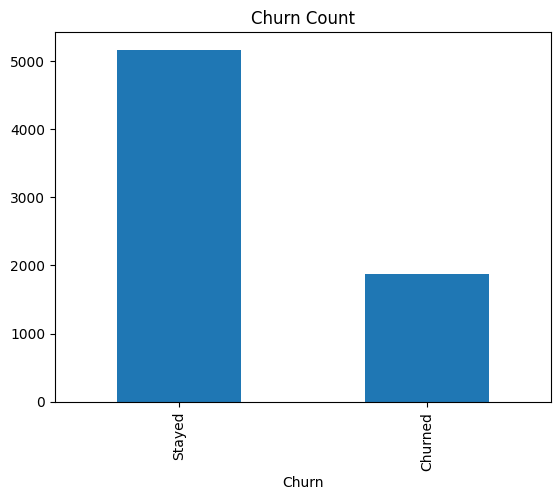

In [ ]:
df['Churn'].value_counts().plot(kind='bar')
plt.title('Churn Count')
plt.xticks([0,1], ['Stayed', 'Churned'])
plt.show()

While the majority of customers (5163) remain with the service, a substantial number (1869) have churned. This imbalance highlights a critical retention issue, as losing over a quarter of the customer base can significantly impact revenue and long-term growth.

In [ ]:
df.groupby('Contract')['Churn'].mean() * 100

,Churn
Contract,
Month-to-month,42.709677
One year,11.277174
Two year,2.848665


Long-term contracts reduce churn significantly

In [ ]:
df.groupby('TenureGroup')['Churn'].mean() * 100

/tmp/ipykernel_22473/821002538.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('TenureGroup')['Churn'].mean() * 100


,Churn
TenureGroup,
0-3 months,56.803045
4-12 months,39.145907
13-24 months,28.710938
24+ months,14.036003


Customers leave early → onboarding problem

In [ ]:
df.groupby('PaymentMethod')['Churn'].mean() * 100

,Churn
PaymentMethod,
Bank transfer (automatic),16.731518
Credit card (automatic),15.253123
Electronic check,45.285412
Mailed check,19.201995


Electronic check → 🔴 higher churn

In [ ]:
df.groupby('InternetService')['Churn'].mean() * 100

,Churn
InternetService,
DSL,18.998344
Fiber optic,41.892765
No,7.434211


Fiber optic users often churn more

In [ ]:
df.groupby('TechSupport')['Churn'].mean() * 100

,Churn
TechSupport,
No,41.647465
No internet service,7.434211
Yes,15.196078


No Tech Support → 🔴 higher churn
Yes → 🟢 lower churn


In [ ]:
#Average charges for Churned vs not Churned

In [ ]:
df.groupby('Churn')['MonthlyCharges'].mean()

,MonthlyCharges
Churn,
0,61.307408
1,74.441332


Higher charges → higher churn

In [ ]:
#Visualizations

In [ ]:
#Churn by Contract (Bar Chart)

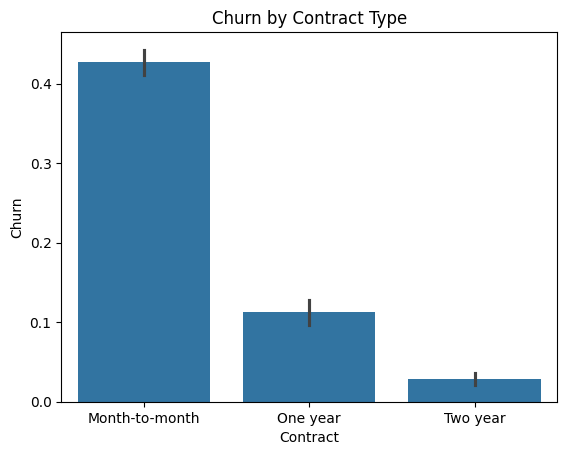

In [ ]:
sns.barplot(x='Contract', y='Churn', data=df)
plt.title('Churn by Contract Type')
plt.show()

In [ ]:
#Churn by Tenure Group

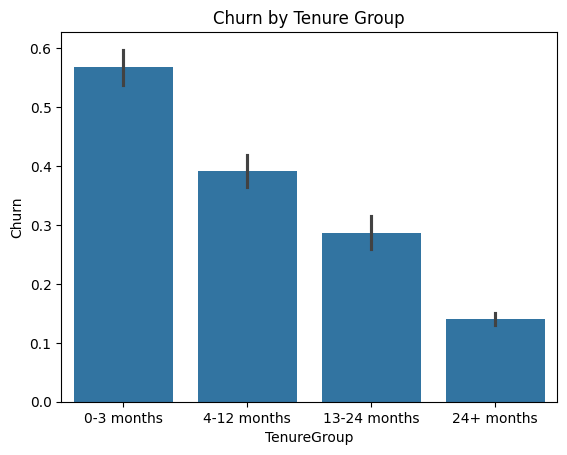

In [ ]:
sns.barplot(x='TenureGroup', y='Churn', data=df)
plt.title('Churn by Tenure Group')
plt.show()

In [ ]:
#Distribution of Monthly Charges

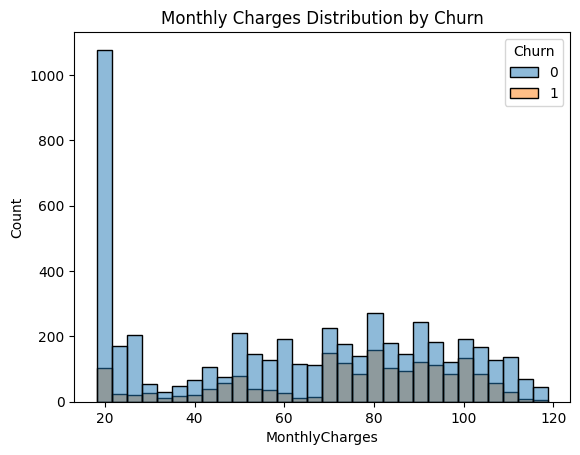

In [ ]:
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', bins=30)
plt.title('Monthly Charges Distribution by Churn')
plt.show()

Customers on month-to-month contracts churn significantly more than long-term subscribers, suggesting contract commitment improves **retention**

In [ ]:
df.to_csv('cleaned_telco_data.csv', index=False)

In [ ]:
from google.colab import files
files.download('Copy of hCleaned_data_Churn_Analysis.csv')

FileNotFoundError: Cannot find file: Copy of Cleaned_data_Churn_Analysis